# GLOBE Data Curation: Exploratory Analysis

This notebook explores the final curated dataset. It visualizes the curation funnel from raw data to the clean dataset, examines the spatial distribution of the measurements, and dives into advanced environmental and instrument analysis. Finally, it isolates individual sites to demonstrate how the Bayesian outlier detection performs in practice.

In [1]:
# =============================================================================
# 1. ENVIRONMENT SETUP
# =============================================================================
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
import warnings
import seaborn as sns
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from IPython.display import display, Markdown

warnings.filterwarnings('ignore')

# Shift the notebook's working directory up to the project root.
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

plt.style.use('seaborn-v0_8-whitegrid')

# Ensure output directory exists for saving diagnostic plots
output_dir = 'output/figures/03_exploratory_analysis'
os.makedirs(output_dir, exist_ok=True)

In [2]:
# =============================================================================
# 2. LOAD DATA FROM MASTER REGISTRY
# =============================================================================

db_path = 'data/master_registry.sqlite'

if not os.path.exists(db_path):
    raise FileNotFoundError(f"Database not found at {db_path}. Ensure Notebook 01 has been run.")

with sqlite3.connect(db_path) as conn:
    print("Connected to Master Registry. Loading tables...")
    df_disk = pd.read_sql("SELECT * FROM measurements_disk", conn)
    df_tube = pd.read_sql("SELECT * FROM measurements_tube", conn)

# Cast SQLite flags to correct boolean types
for df in [df_disk, df_tube]:
    for col in ['passed_heuristics', 'is_censored']:
        if col in df.columns:
            # Binary boolean flags
            df[col] = df[col].fillna(False).astype(bool)
            
    if 'is_statistical_outlier' in df.columns:
        # Ternary logic (True/False/NA). NA = not evaluated or censored.
        df['is_statistical_outlier'] = df['is_statistical_outlier'].astype('boolean')

print(f"Secchi Disk Records: {len(df_disk):,}")
print(f"Transparency Tube Records: {len(df_tube):,}")


Connected to Master Registry. Loading tables...
Secchi Disk Records: 34,038
Transparency Tube Records: 133,440


✅ Curation cascade plot saved to: output/figures/03_exploratory_analysis/exp_curation_cascade.png



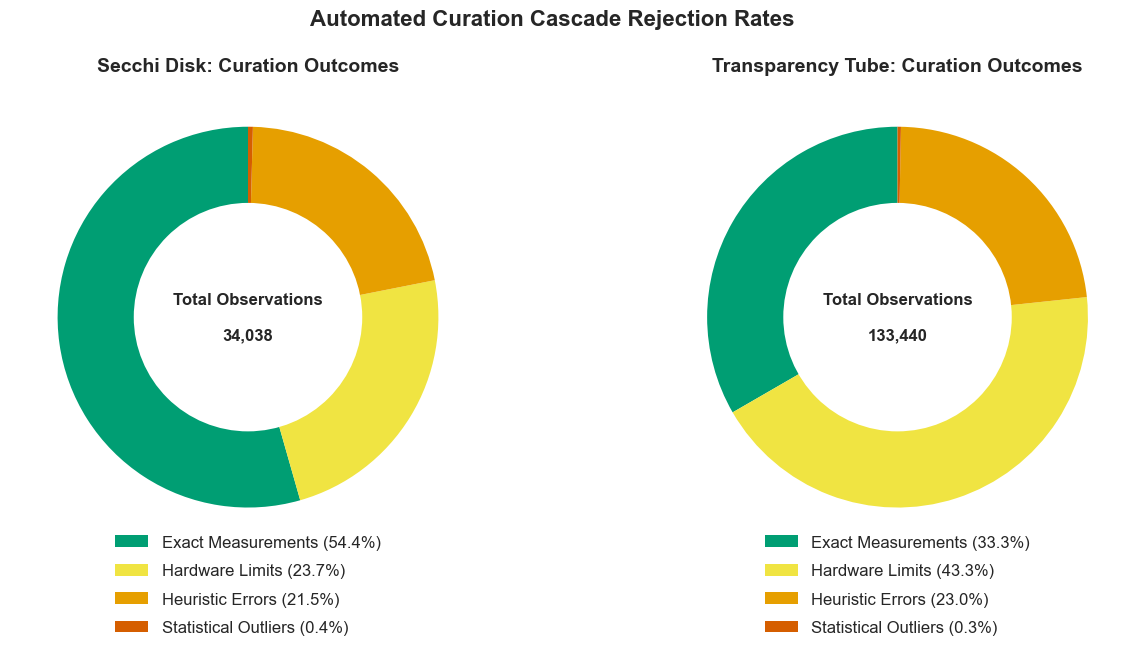


### Interpretation of the Curation Cascade

These charts visualize the macro-level impact of the automated filter, breaking down the exact proportions of data retained versus data rejected by each stage of the pipeline.

**Key Takeaways:**
* **Hardware Limitations (Censored):** The Transparency Tube chart explicitly isolates readings that hit the 120cm physical limit of the plastic tube (yellow). Separating this confirms these are not human errors, but rather right-censored valid observations that require specific mathematical handling.
* **Heuristic Trimming:** The initial heuristic pass (orange) catches the bulk of the obvious observer errors—such as typos, missing values, and physically impossible depths—cleaning up gross anomalies before statistical modeling begins.
* **Bayesian Precision:** The Bayesian Hierarchical Model (vermillion) acts as a highly targeted secondary filter. It rejects a minuscule percentage of the data, surgically removing localized anomalies that passed the basic physical checks but mathematically violate a specific site's historical baseline.
* **Retained Volume:** Ultimately, the pipeline aggressively filters structural noise while retaining a high-confidence subset of exact measurements (Exact Measurements). Combined with the large volume of preserved clear-water boundary events (Hardware Limits), the framework yields a rigorously validated dataset ready for hydrological analysis.


In [3]:
# =============================================================================
# 3. CURATION CASCADE (DONUT CHARTS)
# =============================================================================

# Save high resolution plot image locally
save_plot = True

# Reduce horizontal dead space
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

def plot_donut(ax, df, title):
    total_raw = len(df)

    # Calculate mutually exclusive slices
    censored = df['is_censored'].sum()
    failed_heuristics = len(df[(df['passed_heuristics'] == False) & (df['is_censored'] == False)])
    failed_stats = len(df[(df['passed_heuristics'] == True) & (df['is_statistical_outlier'].eq(True)) & (df['is_censored'] == False)])
    
    # Merge both statistically verified data (False) and historical data that passed heuristics but bypassed the model (NA)
    final_clean = len(df[(df['passed_heuristics'] == True) & (df['is_statistical_outlier'].fillna(False) == False) & (df['is_censored'] == False)])

    raw_labels = ['Exact Measurements', 'Hardware Limits', 'Heuristic Errors', 'Statistical Outliers']
    raw_sizes = [final_clean, censored, failed_heuristics, failed_stats]

    # Set slice colors
    color_curated = '#009E73'
    color_censored = '#F0E442'
    color_heuristic = '#E69F00'
    color_outlier = '#D55E00'

    raw_colors = [color_curated, color_censored, color_heuristic, color_outlier]

    labels, sizes, plot_colors = [], [], []
    for label, size, color in zip(raw_labels, raw_sizes, raw_colors):
        if size > 0:
            labels.append(label)
            sizes.append(size)
            plot_colors.append(color)

    # Draw the pie without internal text to prevent overlapping
    wedges, texts = ax.pie(sizes, colors=plot_colors, startangle=90)

    # Render as a donut chart
    centre_circle = plt.Circle((0,0), 0.60, fc='white')
    ax.add_artist(centre_circle)

    # Display the Total Observations in the center
    ax.text(0, 0, f"Total Observations\n\n{total_raw:,}", ha='center', va='center', fontsize=12, fontweight='bold')

    # Show sub-titles
    ax.set_title(title, fontsize=14, fontweight='bold')

    # Generate legend with percentage labels
    legend_labels = [f"{l} ({s/total_raw*100:.1f}%)" for l, s in zip(labels, sizes)]

    # Tighten legend vertical spacing
    ax.legend(wedges, legend_labels, loc='lower center', bbox_to_anchor=(0.5, -0.20),
              fontsize=12, frameon=False, labelspacing=0.8)

# Generate the plots
plot_donut(axes[0], df_disk, 'Secchi Disk: Curation Outcomes')
plot_donut(axes[1], df_tube, 'Transparency Tube: Curation Outcomes')

# Tighten vertical spacing between title and subplots
plt.suptitle("Automated Curation Cascade Rejection Rates", fontsize=16, y=0.98, fontweight='bold')
plt.subplots_adjust(top=0.88, bottom=0.20, wspace=0.1)

# Save the high resolution plot image
if save_plot:
    donut_fig_path = os.path.join(output_dir, 'exp_curation_cascade.png')
    plt.savefig(donut_fig_path, bbox_inches='tight', dpi=300)
    print(f"✅ Curation cascade plot saved to: {donut_fig_path}\n")

plt.show()

# --- Embedded Interpretation ---
caption_cascade = """
### Interpretation of the Curation Cascade

These charts visualize the macro-level impact of the automated filter, breaking down the exact proportions of data retained versus data rejected by each stage of the pipeline.

**Key Takeaways:**
* **Hardware Limitations (Censored):** The Transparency Tube chart explicitly isolates readings that hit the 120cm physical limit of the plastic tube (yellow). Separating this confirms these are not human errors, but rather right-censored valid observations that require specific mathematical handling.
* **Heuristic Trimming:** The initial heuristic pass (orange) catches the bulk of the obvious observer errors—such as typos, missing values, and physically impossible depths—cleaning up gross anomalies before statistical modeling begins.
* **Bayesian Precision:** The Bayesian Hierarchical Model (vermillion) acts as a highly targeted secondary filter. It rejects a minuscule percentage of the data, surgically removing localized anomalies that passed the basic physical checks but mathematically violate a specific site's historical baseline.
* **Retained Volume:** Ultimately, the pipeline aggressively filters structural noise while retaining a high-confidence subset of exact measurements (Exact Measurements). Combined with the large volume of preserved clear-water boundary events (Hardware Limits), the framework yields a rigorously validated dataset ready for hydrological analysis.
"""
from IPython.display import display, Markdown
display(Markdown(caption_cascade))


## Value Distributions
Comparing the dataset before and after the Bayesian models were applied. This confirms that the statistical models are trimming extreme values without significantly altering the core distribution structure.

✅ KDE distribution plot saved to: output/figures/03_exploratory_analysis/exp_dist_kde_overlay.png



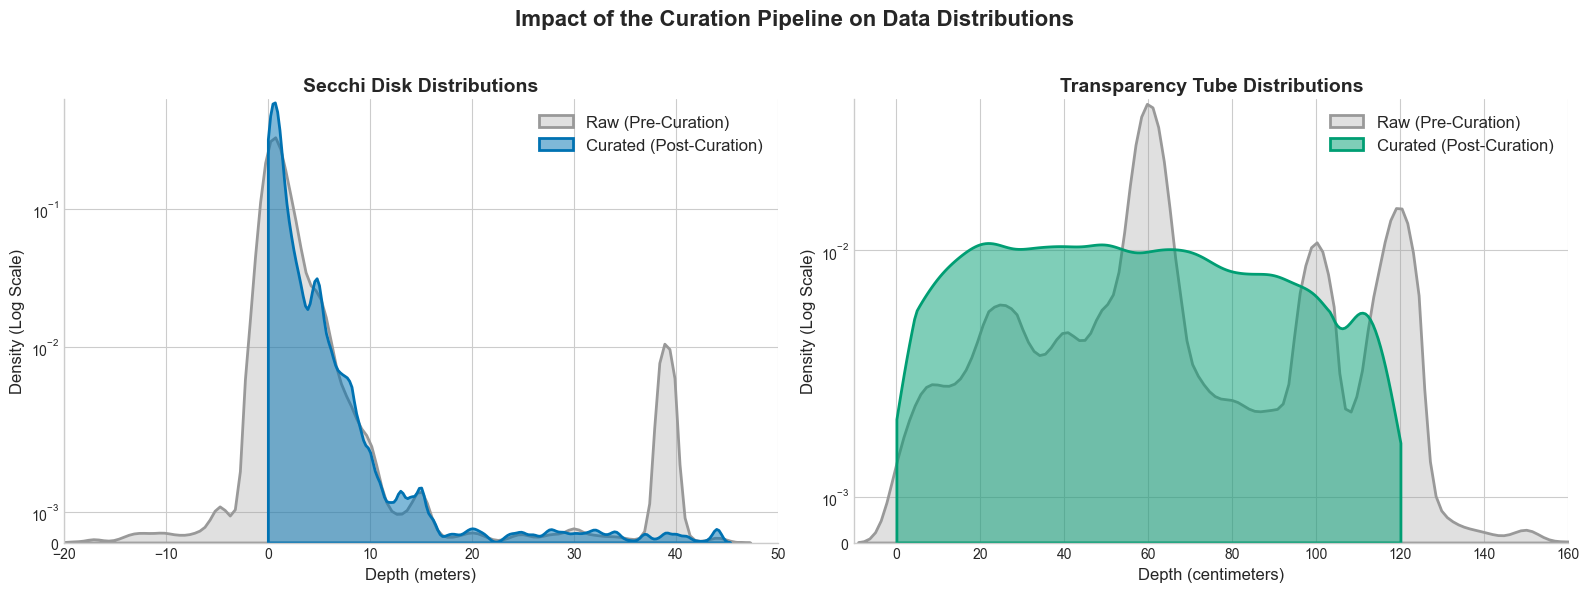


### Interpretation of Value Distributions

These overlaid density plots visualize the structural noise embedded in the raw crowdsourced data (gray) versus the final, mathematically clean dataset (color).

**Key Takeaways:**
* **Exposing the Extremes:** By plotting on a symmetrical logarithmic (symlog) scale, we compress the primary density peaks to visually emphasize boundary extremes. The raw distributions reveal severe physical anomalies and systemic data entry artifacts (e.g., negative values) that would otherwise corrupt ecological modeling.
* **Targeted Trimming & Hardware Limits:** The plotted distributions illustrate the pipeline's effectiveness. For the Transparency Tube, notice the massive artificial density spikes in the raw data at 60cm, 100cm, and 120cm (the physical maximum lengths of commonly used tube models). Rather than allowing these hardware limitations to distort the continuous environmental model, the dynamic Maximum Likelihood Estimation (MLE) logic successfully segregates all of them as right-censored data, smoothly removing the artificial spikes from the visual density plot. *(Note: These censored measurements are fully retained in the final database as 'lower bounds' for modeling, but are excluded from this specific visualization to reveal the true underlying continuous distribution of exact measurements).* 

* **Isolating Microscopic Errors:** The symlog scale visually magnifies isolated boundary artifacts at extreme depths. While prominent in density space, these anomalous spikes represent a microscopic fraction of historical records (<0.01%) caused by human data-entry typos (e.g., logging centimeters as meters). The framework's environmental heuristics deterministically intercept these physical impossibilities.
* **Structural Integrity:** The overall shape and primary density peaks of the valid observations remain entirely stable, yielding a robust, ecologically viable dataset.


In [4]:
# =============================================================================
# 4. PRE VS. POST CURATION DISTRIBUTIONS (KDE)
# =============================================================================

# Save high resolution plot image locally
save_plot = True

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Set colors
color_raw = '#999999'          # Grey
color_disk_curated = '#0072B2' # Blue
color_tube_curated = '#009E73' # Bluish Green

# --- Secchi Disk Overlay ---
disk_raw = df_disk['transparency_disk_image_disappearance_m'].dropna()
disk_clean = df_disk[(df_disk['passed_heuristics'] == True) & (df_disk['is_statistical_outlier'].fillna(False) == False) & (df_disk['is_censored'] == False)]['transparency_disk_image_disappearance_m'].dropna()

# Disable clipping to expose negative typos and extreme outliers
sns.kdeplot(data=disk_raw, ax=axes[0], color=color_raw, fill=True, alpha=0.3,
            linewidth=2, label='Raw (Pre-Curation)')

# Clip at 0 to prevent visualization artifacts; curated data contains no negative values
sns.kdeplot(data=disk_clean, ax=axes[0], color=color_disk_curated, fill=True, alpha=0.5,
            linewidth=2, label='Curated (Post-Curation)', clip=(0, None))

axes[0].set_title('Secchi Disk Distributions', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Depth (meters)', fontsize=12)
axes[0].set_ylabel('Density (Log Scale)', fontsize=12)
axes[0].legend(fontsize=12)

# Restrict axis limits to the structurally relevant density, excluding near-zero outliers.
axes[0].set_xlim(-20, 50)
axes[0].set_yscale('symlog', linthresh=0.005)

# --- Transparency Tube Overlay ---
tube_raw = df_tube['tube_image_disappearance_cm'].dropna()
tube_clean = df_tube[(df_tube['passed_heuristics'] == True) & (df_tube['is_statistical_outlier'].fillna(False) == False) & (df_tube['is_censored'] == False)]['tube_image_disappearance_cm'].dropna()

# Disable clipping to expose negative typos and extreme outliers
sns.kdeplot(data=tube_raw, ax=axes[1], color=color_raw, fill=True, alpha=0.3,
            linewidth=2, label='Raw (Pre-Curation)')

# Clip at 0 and 120 to prevent visualization artifacts; curated data contains no negative or >120cm values.
sns.kdeplot(data=tube_clean, ax=axes[1], color=color_tube_curated, fill=True, alpha=0.5,
            linewidth=2, label='Curated (Post-Curation)', clip=(0, 120))

axes[1].set_title('Transparency Tube Distributions', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Depth (centimeters)', fontsize=12)
axes[1].set_ylabel('Density (Log Scale)', fontsize=12)
axes[1].legend(fontsize=12)

# Restrict axis limits to the structurally relevant density, excluding near-zero outliers.
axes[1].set_xlim(-10, 160)
axes[1].set_yscale('symlog', linthresh=0.005)

# Remove top and right spines
for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle("Impact of the Curation Pipeline on Data Distributions", fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])

# Save the high resolution plot image
if save_plot:
    kde_fig_path = os.path.join(output_dir, 'exp_dist_kde_overlay.png')
    plt.savefig(kde_fig_path, bbox_inches='tight', dpi=300)
    print(f"✅ KDE distribution plot saved to: {kde_fig_path}\n")

plt.show()

# --- Embedded Interpretation ---
caption_kde = """
### Interpretation of Value Distributions

These overlaid density plots visualize the structural noise embedded in the raw crowdsourced data (gray) versus the final, mathematically clean dataset (color).

**Key Takeaways:**
* **Exposing the Extremes:** By plotting on a symmetrical logarithmic (symlog) scale, we compress the primary density peaks to visually emphasize boundary extremes. The raw distributions reveal severe physical anomalies and systemic data entry artifacts (e.g., negative values) that would otherwise corrupt ecological modeling.
* **Targeted Trimming & Hardware Limits:** The plotted distributions illustrate the pipeline's effectiveness. For the Transparency Tube, notice the massive artificial density spikes in the raw data at 60cm, 100cm, and 120cm (the physical maximum lengths of commonly used tube models). Rather than allowing these hardware limitations to distort the continuous environmental model, the dynamic Maximum Likelihood Estimation (MLE) logic successfully segregates all of them as right-censored data, smoothly removing the artificial spikes from the visual density plot. *(Note: These censored measurements are fully retained in the final database as 'lower bounds' for modeling, but are excluded from this specific visualization to reveal the true underlying continuous distribution of exact measurements).* \n
* **Isolating Microscopic Errors:** The symlog scale visually magnifies isolated boundary artifacts at extreme depths. While prominent in density space, these anomalous spikes represent a microscopic fraction of historical records (<0.01%) caused by human data-entry typos (e.g., logging centimeters as meters). The framework's environmental heuristics deterministically intercept these physical impossibilities.
* **Structural Integrity:** The overall shape and primary density peaks of the valid observations remain entirely stable, yielding a robust, ecologically viable dataset.
"""
display(Markdown(caption_kde))

## Spatial Distribution of Outliers
Visualizing the global footprint of the measurements. Outliers are plotted on top of curated measurements to determine if anomalies are geographically clustered or uniformly distributed.

✅ Global spatial map saved successfully to: output/figures/03_exploratory_analysis/exp_spatial_distribution.png



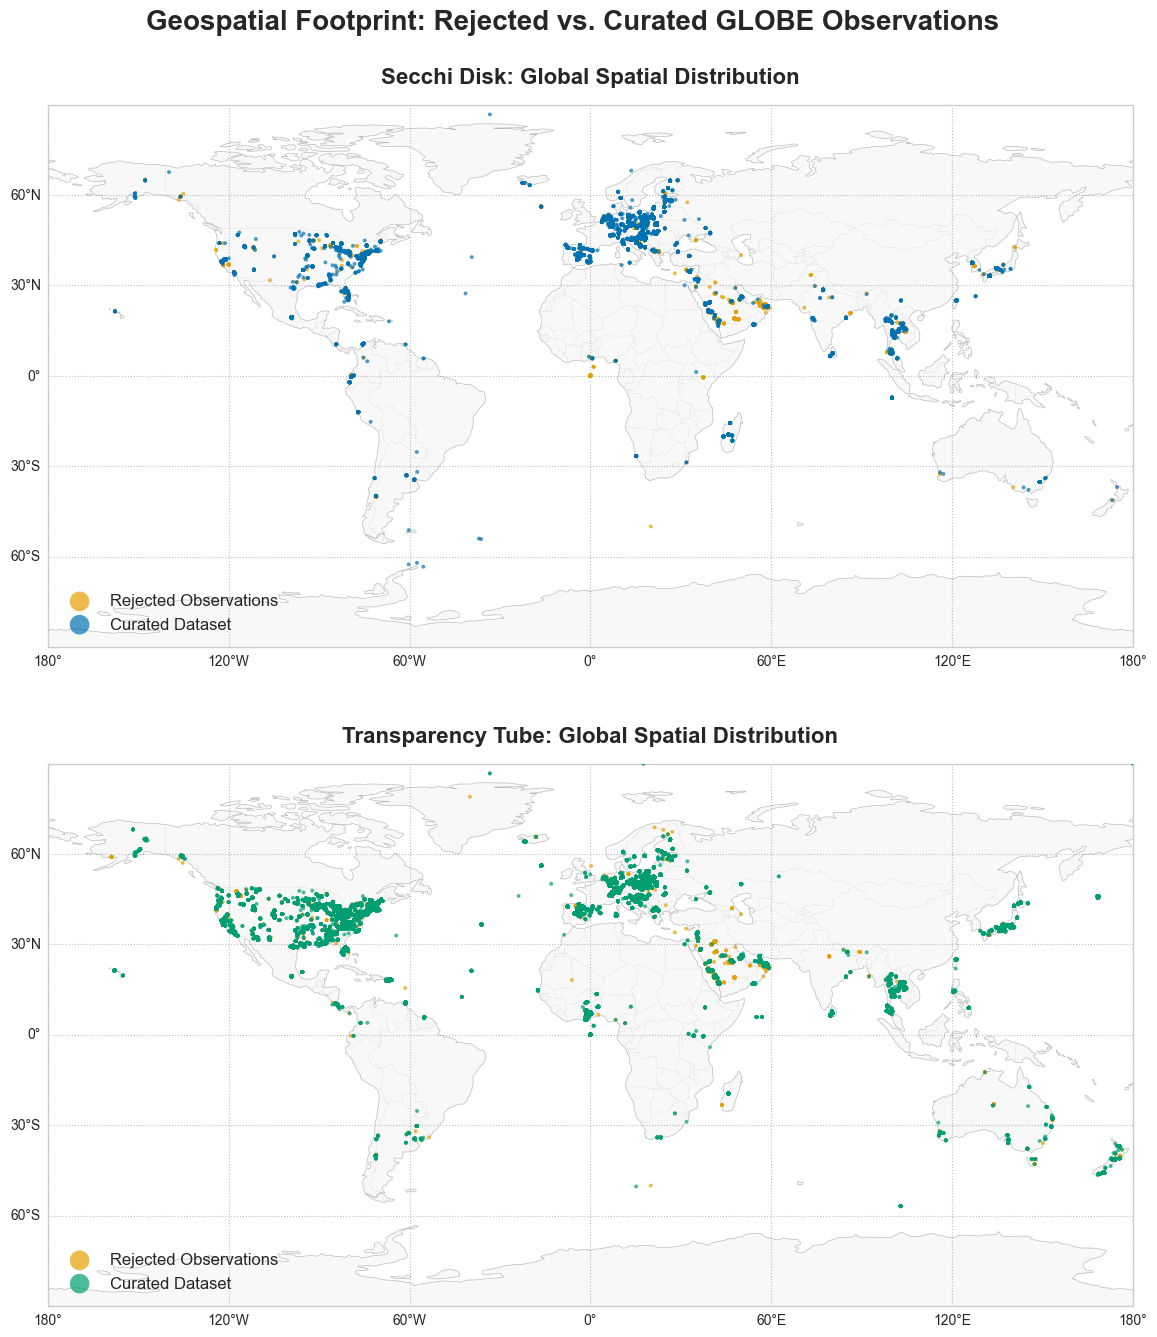


### Interpretation of Spatial Distributions

These maps visualize the global footprint of the NASA GLOBE hydrological dataset, contrasting the explicitly rejected submissions (orange) with the final curated observations (color).

**Key Takeaways:**
* **Geographic Reach:** The program demonstrates massive spatial coverage, with heavy cluster densities across North America, Europe, and distinct localized networks in the Global South.
* **Instrument Bias:** A distinct spatial divide exists between the two methodologies. The Secchi Disk (blue) is overwhelmingly favored in North America and Europe, while the Transparency Tube (green) sees higher relative utilization across Africa, Asia, and South America, likely due to its portability and utility in shallow, highly turbid water systems.
* **Unbiased Curation:** Crucially, the curation pipeline (heuristic and Bayesian trimming) does not introduce geographic bias. The rejected observations (orange dots) are distributed randomly throughout the global network, confirming that the model surgically removes errors without inadvertently censoring specific regions or countries.


In [5]:
# =============================================================================
# 5. GLOBAL SPATIAL MAPS
# =============================================================================

# Save high resolution plot image locally
save_plot = True

# Set colors
color_raw = '#E69F00'          # Orange (Explicitly Rejected)
color_disk_curated = '#0072B2' # Blue
color_tube_curated = '#009E73' # Bluish Green

# Use standard PlateCarree projection
projection = ccrs.PlateCarree()

# Create 2x1 plot
fig, axes = plt.subplots(2, 1, figsize=(14, 16), subplot_kw={'projection': projection})

# 1. Extract curated datasets
disk_clean = df_disk[(df_disk['passed_heuristics'] == True) & (df_disk['is_statistical_outlier'].fillna(False) == False)]
tube_clean = df_tube[(df_tube['passed_heuristics'] == True) & (df_tube['is_statistical_outlier'].fillna(False) == False)]

# 2. Extract explicitly rejected datasets
disk_rejected = df_disk.drop(disk_clean.index)
tube_rejected = df_tube.drop(tube_clean.index)

def setup_map(ax, title):
    ax.add_feature(cfeature.LAND, facecolor='#f8f8f8', zorder=0)
    ax.add_feature(cfeature.OCEAN, facecolor='#ffffff', zorder=0)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor='#bcbcbc', zorder=1)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3, edgecolor='#dcdcdc', zorder=1)

    ax.set_global()
    ax.set_title(title, fontsize=16, fontweight='bold', pad=15)

    gl = ax.gridlines(draw_labels=True, linestyle=':', color='gray', alpha=0.5, zorder=1)
    gl.top_labels = False
    gl.right_labels = False

# --- Secchi Disk Map (Top) ---
setup_map(axes[0], 'Secchi Disk: Global Spatial Distribution')

# Plot Rejected Data (Orange)
axes[0].scatter(disk_rejected['longitude'], disk_rejected['latitude'],
                color=color_raw, s=8, alpha=0.7, edgecolors='none', transform=ccrs.PlateCarree(),
                label='Rejected Observations', zorder=2)

# Plot Curated Data (Blue)
axes[0].scatter(disk_clean['longitude'], disk_clean['latitude'],
                color=color_disk_curated, s=8, alpha=0.7, edgecolors='none',
                transform=ccrs.PlateCarree(), label='Curated Dataset', zorder=3)

# Increase markerscale so the legend dots don't become invisible
axes[0].legend(loc='lower left', framealpha=0.9, fontsize=12, markerscale=5)

# --- Transparency Tube Map (Bottom) ---
setup_map(axes[1], 'Transparency Tube: Global Spatial Distribution')

# Plot Rejected Data (Orange)
axes[1].scatter(tube_rejected['longitude'], tube_rejected['latitude'],
                color=color_raw, s=8, alpha=0.7, edgecolors='none', transform=ccrs.PlateCarree(),
                label='Rejected Observations', zorder=2)

# Plot Curated Data (Green)
axes[1].scatter(tube_clean['longitude'], tube_clean['latitude'],
                color=color_tube_curated, s=8, alpha=0.7, edgecolors='none',
                transform=ccrs.PlateCarree(), label='Curated Dataset', zorder=3)

axes[1].legend(loc='lower left', framealpha=0.9, fontsize=12, markerscale=5)

plt.suptitle("Geospatial Footprint: Rejected vs. Curated GLOBE Observations", fontsize=20, y=0.93, fontweight='bold')
plt.subplots_adjust(hspace=0.15)

# Save the high resolution plot image
if save_plot:
    map_fig_path = os.path.join(output_dir, 'exp_spatial_distribution.png')
    plt.savefig(map_fig_path, bbox_inches='tight', dpi=300)
    print(f"✅ Global spatial map saved successfully to: {map_fig_path}\n")

plt.show()

# --- Embedded Interpretation ---
caption_map = """
### Interpretation of Spatial Distributions

These maps visualize the global footprint of the NASA GLOBE hydrological dataset, contrasting the explicitly rejected submissions (orange) with the final curated observations (color).

**Key Takeaways:**
* **Geographic Reach:** The program demonstrates massive spatial coverage, with heavy cluster densities across North America, Europe, and distinct localized networks in the Global South.
* **Instrument Bias:** A distinct spatial divide exists between the two methodologies. The Secchi Disk (blue) is overwhelmingly favored in North America and Europe, while the Transparency Tube (green) sees higher relative utilization across Africa, Asia, and South America, likely due to its portability and utility in shallow, highly turbid water systems.
* **Unbiased Curation:** Crucially, the curation pipeline (heuristic and Bayesian trimming) does not introduce geographic bias. The rejected observations (orange dots) are distributed randomly throughout the global network, confirming that the model surgically removes errors without inadvertently censoring specific regions or countries.
"""
display(Markdown(caption_map))

## Instrument Concordance
Validating the physical consistency of the curation framework by evaluating rare, concurrent deployments where both a Secchi Disk and a Transparency Tube were used simultaneously.

✅ Concordance plot saved to: output/figures/03_exploratory_analysis/exp_instrument_concordance.png


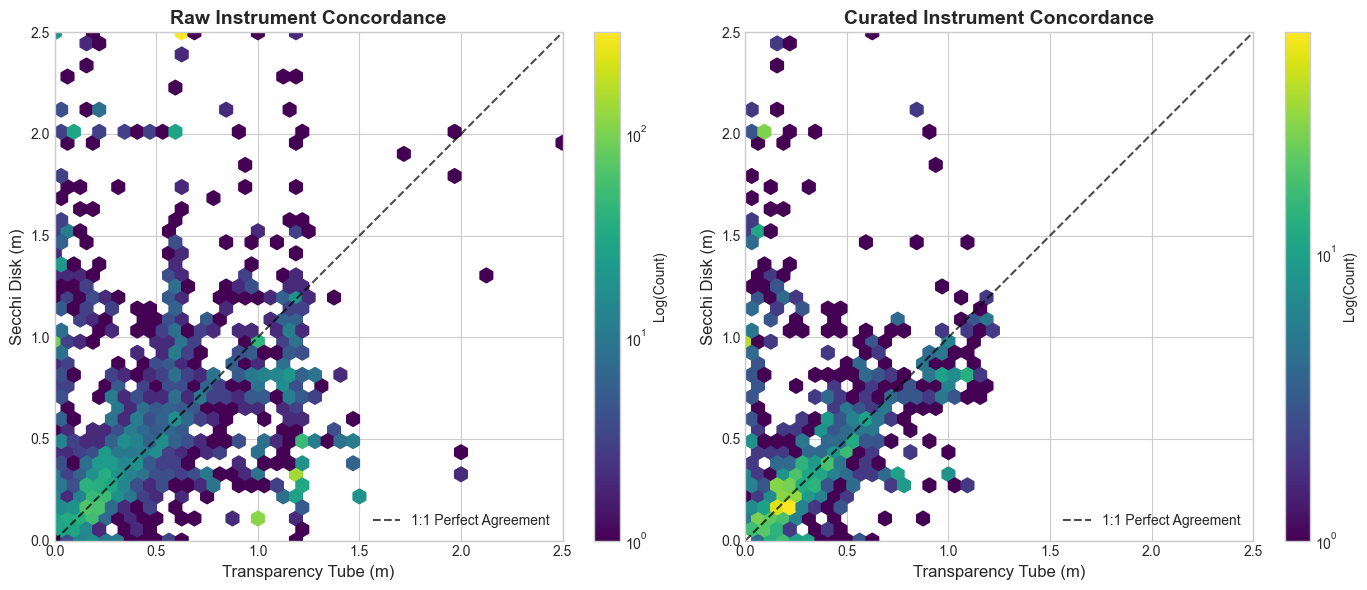


### Interpretation of Instrument Concordance

To mathematically validate the automated filter, this analysis isolates the rare subset of concurrent deployments where observers utilized both instruments simultaneously. 

**Key Takeaways:**
* **Theoretical Baseline:** Because the Secchi disk and transparency tube rely on identical optical principles, paired observations establish a theoretical 1:1 baseline (the dashed black line).
* **Noise Reduction:** The raw paired data (left) exhibits severe scatter and impossible physical boundary artifacts. The automated curation pipeline (right) resolves these systematic errors and explicitly filters out right-censored hardware limits, yielding a refined dataset of physically viable concurrent measurements and justifying its application to the broader, unpaired dataset.


In [6]:
# =============================================================================
# 6. CROSS-INSTRUMENT CONCORDANCE (RAW VS CURATED)
# =============================================================================

# Save high resolution plot image locally
save_plot = True

# Isolate only the necessary columns before merging
disk_subset = df_disk[['site_id', 'measured_on', 'transparency_disk_image_disappearance_m', 'passed_heuristics', 'is_statistical_outlier', 'is_censored']].dropna(subset=['transparency_disk_image_disappearance_m'])
tube_subset = df_tube[['site_id', 'measured_on', 'tube_image_disappearance_cm', 'passed_heuristics', 'is_statistical_outlier', 'is_censored']].dropna(subset=['tube_image_disappearance_cm'])

# Merge datasets to find instances where both instruments were used concurrently (inner join)
concordance_df = pd.merge(
    disk_subset, tube_subset,
    on=['site_id', 'measured_on'],
    suffixes=('_disk', '_tube'),
    how='inner'
)

# Convert Transparency Tube depth (cm) to meters for 1:1 comparison
concordance_df['tube_image_disappearance_m'] = concordance_df['tube_image_disappearance_cm'] / 100

# Filter out placeholder zeros that create false density at the origin
concordance_df = concordance_df[
    (concordance_df['transparency_disk_image_disappearance_m'] > 0) &
    (concordance_df['tube_image_disappearance_m'] > 0)
]

# Identify records where both the tube and disk measurements passed all curation checks
concordance_df['both_curated'] = (
    (concordance_df['passed_heuristics_disk'] == True) & (concordance_df['is_statistical_outlier_disk'].fillna(False) == False) & (concordance_df['is_censored_disk'] == False) &
    (concordance_df['passed_heuristics_tube'] == True) & (concordance_df['is_statistical_outlier_tube'].fillna(False) == False) & (concordance_df['is_censored_tube'] == False)
)

curated_concordance = concordance_df[concordance_df['both_curated']]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
cmap = plt.cm.viridis

# Plot 1: Raw Concordance (All paired records)
hb1 = axes[0].hexbin(concordance_df['tube_image_disappearance_m'], concordance_df['transparency_disk_image_disappearance_m'],
                     gridsize=40, cmap=cmap, bins='log', mincnt=1, extent=[0, 2.5, 0, 2.5])
axes[0].plot([0, 2.5], [0, 2.5], 'k--', alpha=0.7, label="1:1 Perfect Agreement")
axes[0].set_title('Raw Instrument Concordance', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Transparency Tube (m)', fontsize=12)
axes[0].set_ylabel('Secchi Disk (m)', fontsize=12)
axes[0].set_xlim(0, 2.5)
axes[0].set_ylim(0, 2.5)
axes[0].legend(loc='lower right')
fig.colorbar(hb1, ax=axes[0], label='Log(Count)')

# Plot 2: Curated Concordance (Only pristine paired records)
hb2 = axes[1].hexbin(curated_concordance['tube_image_disappearance_m'], curated_concordance['transparency_disk_image_disappearance_m'],
                     gridsize=40, cmap=cmap, bins='log', mincnt=1, extent=[0, 2.5, 0, 2.5])
axes[1].plot([0, 2.5], [0, 2.5], 'k--', alpha=0.7, label="1:1 Perfect Agreement")
axes[1].set_title('Curated Instrument Concordance', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Transparency Tube (m)', fontsize=12)
axes[1].set_ylabel('Secchi Disk (m)', fontsize=12)
axes[1].set_xlim(0, 2.5)
axes[1].set_ylim(0, 2.5)
axes[1].legend(loc='lower right')
fig.colorbar(hb2, ax=axes[1], label='Log(Count)')

plt.tight_layout()

# Save the high resolution plot image
if save_plot:
    fig_path = os.path.join(output_dir, 'exp_instrument_concordance.png')
    plt.savefig(fig_path, bbox_inches='tight', dpi=300)
    print(f"✅ Concordance plot saved to: {fig_path}")
    
plt.show()

# --- Embedded Interpretation ---
caption_concordance = """
### Interpretation of Instrument Concordance

To mathematically validate the automated filter, this analysis isolates the rare subset of concurrent deployments where observers utilized both instruments simultaneously. 

**Key Takeaways:**
* **Theoretical Baseline:** Because the Secchi disk and transparency tube rely on identical optical principles, paired observations establish a theoretical 1:1 baseline (the dashed black line).
* **Noise Reduction:** The raw paired data (left) exhibits severe scatter and impossible physical boundary artifacts. The automated curation pipeline (right) resolves these systematic errors and explicitly filters out right-censored hardware limits, yielding a refined dataset of physically viable concurrent measurements and justifying its application to the broader, unpaired dataset.
"""
display(Markdown(caption_concordance))

## Seasonal Distributions Over Time
Exploring natural environmental cycling by plotting the monthly distributions of curated water transparency data.

✅ Seasonal distributions plot saved to: output/figures/03_exploratory_analysis/exp_seasonal_distributions.png



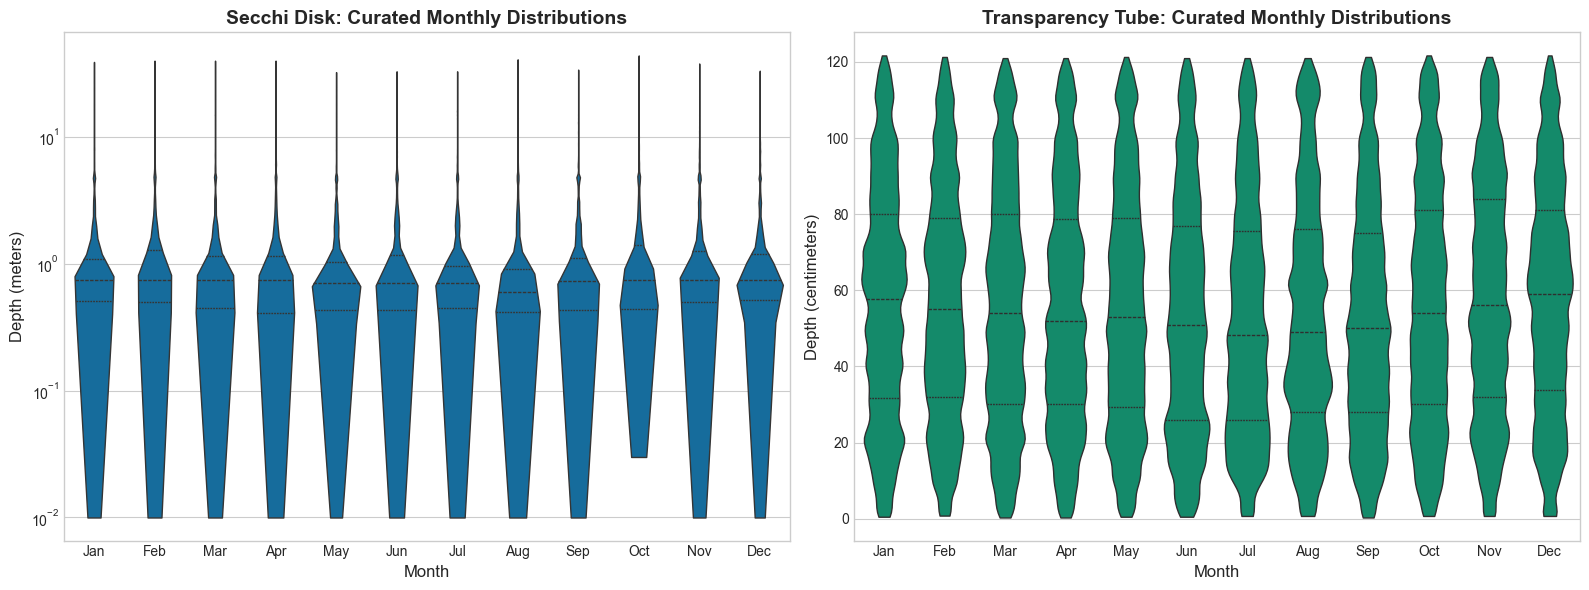


### Interpretation of Seasonal Distributions

These violin plots map the global distribution of valid water transparency readings across the calendar year, leveraging the full weight of both recent and historical (>10 years) data.

**Key Takeaways:**
* **Secchi Disk Seasonality:** The Secchi Disk data captures natural seasonal oscillations. Median transparency decreases steadily through the spring, reaching its lowest point during the early Northern Hemisphere summer (May-July) due to increased biological productivity and early-summer algal blooms. Transparency then recovers through late summer and remains higher during the colder winter months.
* **Transparency Tube Seasonality:** While severely dampened by the hardware ceiling, the Transparency Tube distributions trace a similar seasonal ecological signal to the Secchi Disk—a dip in transparency during the summer months followed by a recovery in the winter. The curation pipeline successfully reveals this underlying signal by mathematically isolating right-censored readings (i.e., hardware limitations at 60cm, 100cm, and 120cm), substantially mitigating the artificial structural bulges that previously masked the true continuous distribution.
* **Curation Impact:** The preservation of these expected natural seasonal oscillations across both instruments confirms the robustness of the curation framework. By handling hardware censoring mathematically rather than treating it as a standard continuous variable, we ensure the ecological data is completely unobstructed and ready for accurate hydrological modeling.


In [7]:
# =============================================================================
# 7. SEASONAL DISTRIBUTIONS OVER TIME
# =============================================================================

# Save high resolution plot image locally
save_plot = True

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Extract clean data and parse months
disk_valid = df_disk[(df_disk['passed_heuristics'] == True) & (df_disk['is_statistical_outlier'].fillna(False) == False) & (df_disk['is_censored'] == False) & (df_disk['latitude'] >= 0)].copy()
disk_valid['measured_on'] = pd.to_datetime(disk_valid['measured_on'], format='mixed', errors='coerce')
disk_valid['month'] = disk_valid['measured_on'].dt.month.dropna().astype(int)

tube_valid = df_tube[(df_tube['passed_heuristics'] == True) & (df_tube['is_statistical_outlier'].fillna(False) == False) & (df_tube['is_censored'] == False) & (df_tube['latitude'] >= 0)].copy()
tube_valid['measured_on'] = pd.to_datetime(tube_valid['measured_on'], format='mixed', errors='coerce')
tube_valid['month'] = tube_valid['measured_on'].dt.month.dropna().astype(int)

month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Plot 1: Secchi Disk Seasonality
# bw_adjust=0.4 to prevent KDE over-smoothing
sns.violinplot(data=disk_valid, x='month', y='transparency_disk_image_disappearance_m', ax=axes[0],
               color="#0072B2", inner="quartile", linewidth=1, cut=0, bw_adjust=0.4)
axes[0].set_title('Secchi Disk: Curated Monthly Distributions', fontsize=14, fontweight='bold')
axes[0].set_yscale('log')
axes[0].set_xlabel('Month', fontsize=12)
axes[0].set_ylabel('Depth (meters)', fontsize=12)
axes[0].set_xticks(range(12))
axes[0].set_xticklabels(month_labels)

# Plot 2: Transparency Tube Seasonality
sns.violinplot(data=tube_valid, x='month', y='tube_image_disappearance_cm', ax=axes[1],
               color="#009E73", inner="quartile", linewidth=1, cut=0, bw_adjust=0.4)
axes[1].set_title('Transparency Tube: Curated Monthly Distributions', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Month', fontsize=12)
axes[1].set_ylabel('Depth (centimeters)', fontsize=12)
axes[1].set_xticks(range(12))
axes[1].set_xticklabels(month_labels)

plt.tight_layout()

# Save the high resolution plot image
if save_plot:
    fig_path = os.path.join(output_dir, 'exp_seasonal_distributions.png')
    plt.savefig(fig_path, bbox_inches='tight', dpi=300)
    print(f"✅ Seasonal distributions plot saved to: {fig_path}\n")

plt.show()

# --- Embedded Interpretation ---
caption_seasonal = """
### Interpretation of Seasonal Distributions

These violin plots map the global distribution of valid water transparency readings across the calendar year, leveraging the full weight of both recent and historical (>10 years) data.

**Key Takeaways:**
* **Secchi Disk Seasonality:** The Secchi Disk data captures natural seasonal oscillations. Median transparency decreases steadily through the spring, reaching its lowest point during the early Northern Hemisphere summer (May-July) due to increased biological productivity and early-summer algal blooms. Transparency then recovers through late summer and remains higher during the colder winter months.
* **Transparency Tube Seasonality:** While severely dampened by the hardware ceiling, the Transparency Tube distributions trace a similar seasonal ecological signal to the Secchi Disk—a dip in transparency during the summer months followed by a recovery in the winter. The curation pipeline successfully reveals this underlying signal by mathematically isolating right-censored readings (i.e., hardware limitations at 60cm, 100cm, and 120cm), substantially mitigating the artificial structural bulges that previously masked the true continuous distribution.
* **Curation Impact:** The preservation of these expected natural seasonal oscillations across both instruments confirms the robustness of the curation framework. By handling hardware censoring mathematically rather than treating it as a standard continuous variable, we ensure the ecological data is completely unobstructed and ready for accurate hydrological modeling.
"""
display(Markdown(caption_seasonal))

## Error Rates by Environmental Context
Cross-referencing pipeline rejection rates against the physical attributes of the sampled water bodies to identify environmental drivers of observer error.

✅ Environmental Context plot saved to: output/figures/03_exploratory_analysis/exp_environmental_context.png


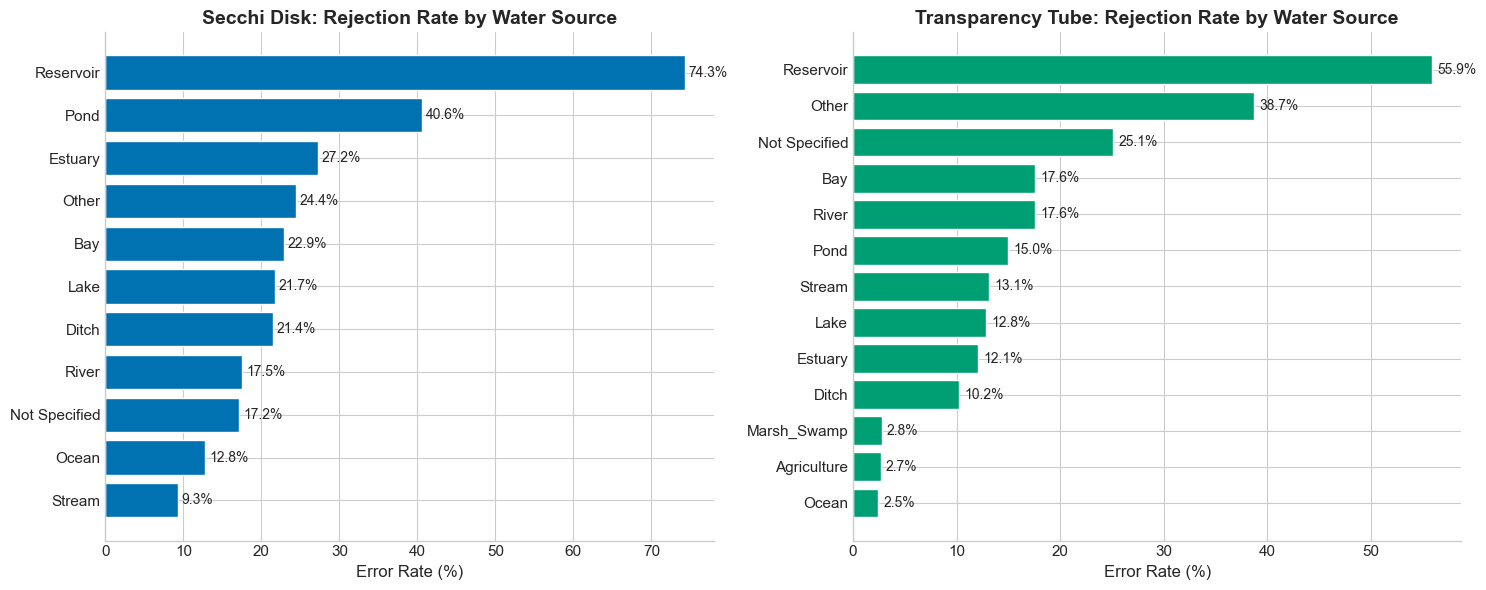


### Interpretation of Environmental Error Context

This analysis cross-references the pipeline's overall rejection rates against the static metadata of the sampled water bodies to identify conditions susceptible to observer error.

**Key Takeaways:**
* **The Reservoir Anomaly:** Both instruments exhibit uniquely massive rejection rates in Reservoirs (74.3% for Secchi Disks, 55.9% for Tubes). Because reservoirs are artificially managed water bodies subject to extreme depth fluctuations (e.g., dam releases and seasonal drawdowns), their ecological baselines are highly non-stationary. This volatility frequently triggers the Bayesian model's localized outlier detection algorithms.
* **Hardware-Environment Dynamics:** The variability across other environments highlights the physical characteristics of the hardware. For instance, Transparency Tubes see near-zero rejection rates in Oceans (2.5%) or Agricultural runoff (2.7%). In these extreme environments, readings consistently trigger valid right-censored limits (e.g., hitting the 120cm tube ceiling in clear oceans) or remain trivially shallow (turbid runoff), which are perfectly valid measurements that correctly bypass statistical rejection.


In [8]:
# =============================================================================
# 8. ERROR RATES BY ENVIRONMENTAL CONTEXT
# =============================================================================

# Save high resolution plot image locally
save_plot = True

with sqlite3.connect(db_path) as conn:
    # Dynamically locate the table containing environmental source data
    tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)['name'].tolist()
    target_table = None
    for tbl in tables:
        cols = pd.read_sql(f"PRAGMA table_info({tbl})", conn)['name'].tolist()
        if 'water_body_source' in cols:
            target_table = tbl
            break

    if target_table:
        df_sites_env = pd.read_sql(f"SELECT site_id, water_body_source FROM {target_table}", conn)
    else:
        df_sites_env = pd.DataFrame(columns=['site_id', 'water_body_source'])

# Cast to string to prevent merge conflicts
df_sites_env['site_id'] = df_sites_env['site_id'].astype(str)
df_sites_env = df_sites_env.drop_duplicates(subset=['site_id'])

def calc_env_rejection(df, sites_df):
    if df.empty or sites_df.empty:
        return pd.DataFrame()

    temp_df = df.copy()
    temp_df['site_id'] = temp_df['site_id'].astype(str)
    temp_df = pd.merge(temp_df, sites_df, on='site_id', how='left')
    
    # Clean up categories
    temp_df['water_body_source'] = temp_df['water_body_source'].fillna('Not Specified')
    temp_df['water_body_source'] = temp_df['water_body_source'].str.title()
    
    # Calculate Total Rejections (Failed heuristics OR Statistical Outlier)
    temp_df['is_rejected'] = (~temp_df['passed_heuristics']) | (temp_df['is_statistical_outlier'].eq(True))
    
    env_stats = temp_df.groupby('water_body_source').agg(
        total_obs=('site_id', 'count'),
        invalid_obs=('is_rejected', 'sum')
    )
    
    # Require at least 50 observations to prevent small-sample size skew
    env_stats = env_stats[env_stats['total_obs'] > 50].copy()
    if env_stats.empty: return pd.DataFrame()
    
    env_stats['rejection_rate'] = (env_stats['invalid_obs'] / env_stats['total_obs']) * 100
    return env_stats.sort_values('rejection_rate')

disk_env = calc_env_rejection(df_disk, df_sites_env)
tube_env = calc_env_rejection(df_tube, df_sites_env)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

if not disk_env.empty and not tube_env.empty:
    axes[0].barh(disk_env.index, disk_env['rejection_rate'], color="#0072B2", edgecolor='white')
    axes[0].set_title('Secchi Disk: Rejection Rate by Water Source', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Error Rate (%)', fontsize=12)

    axes[1].barh(tube_env.index, tube_env['rejection_rate'], color="#009E73", edgecolor='white')
    axes[1].set_title('Transparency Tube: Rejection Rate by Water Source', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Error Rate (%)', fontsize=12)

    # Clean formatting and data label injection
    for ax in axes:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.tick_params(labelsize=11)
        for i, v in enumerate(ax.patches):
            ax.text(v.get_width() + 0.5, v.get_y() + v.get_height()/2,
                    f"{v.get_width():.1f}%", va='center', fontsize=10)

plt.tight_layout()

# Save the high resolution plot image
if save_plot:
    fig_path = os.path.join(output_dir, 'exp_environmental_context.png')
    plt.savefig(fig_path, bbox_inches='tight', dpi=300)
    print(f"✅ Environmental Context plot saved to: {fig_path}")
    
plt.show()

# --- Embedded Interpretation ---

# Dynamically extract percentages for the caption
def get_rate(df, env):
    return f"{df.loc[env, 'rejection_rate']:.1f}%" if env in df.index else "N/A"

res_disk = get_rate(disk_env, 'Reservoir')
res_tube = get_rate(tube_env, 'Reservoir')
ocean_tube = get_rate(tube_env, 'Ocean')
agri_tube = get_rate(tube_env, 'Agriculture')

caption_env = f"""
### Interpretation of Environmental Error Context

This analysis cross-references the pipeline's overall rejection rates against the static metadata of the sampled water bodies to identify conditions susceptible to observer error.

**Key Takeaways:**
* **The Reservoir Anomaly:** Both instruments exhibit uniquely massive rejection rates in Reservoirs ({res_disk} for Secchi Disks, {res_tube} for Tubes). Because reservoirs are artificially managed water bodies subject to extreme depth fluctuations (e.g., dam releases and seasonal drawdowns), their ecological baselines are highly non-stationary. This volatility frequently triggers the Bayesian model's localized outlier detection algorithms.
* **Hardware-Environment Dynamics:** The variability across other environments highlights the physical characteristics of the hardware. For instance, Transparency Tubes see near-zero rejection rates in Oceans ({ocean_tube}) or Agricultural runoff ({agri_tube}). In these extreme environments, readings consistently trigger valid right-censored limits (e.g., hitting the 120cm tube ceiling in clear oceans) or remain trivially shallow (turbid runoff), which are perfectly valid measurements that correctly bypass statistical rejection.
"""
display(Markdown(caption_env))

## Site-Level Time Series Analysis
Extracting a single, high-density site to observe the exact measurements that were flagged as outliers against the historical baseline.

✅ Time series plot saved to: output/figures/03_exploratory_analysis/exp_timeseries_site_137384.png


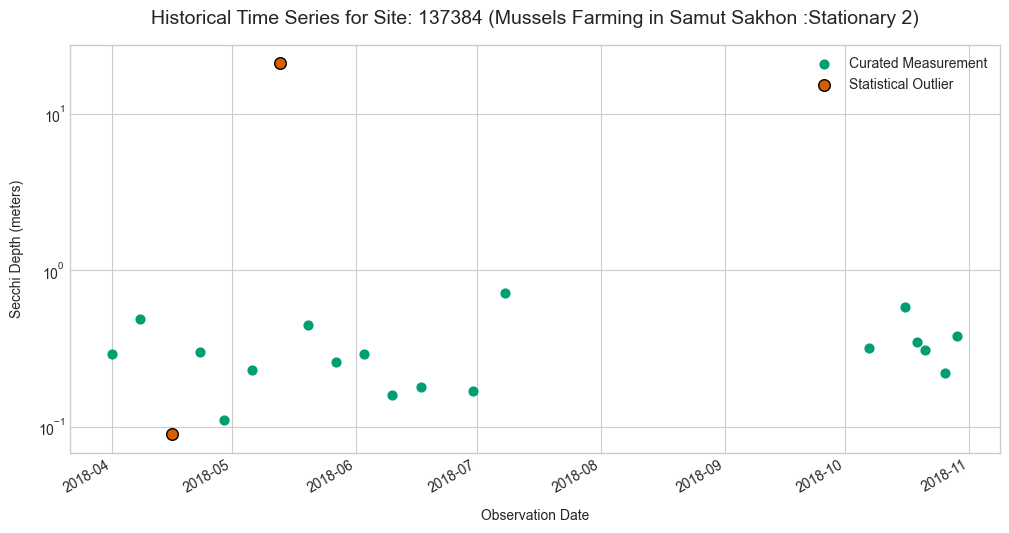


### Interpretation of Site-Level Curation

By isolating Site 137384, we can observe the Bayesian outlier detection in its natural context.

**Key Takeaways:**
* **Historical Baseline:** The model establishes a continuous, site-specific expected range for water transparency based on the site's own historical variance and water body type.
* **Non-Destructive Curation:** Notice the flagged anomalies (categorized as Statistical Outliers). These represent statistically significant deviations that fall just outside the localized prediction interval. The model relies on strict mathematical bounds to isolate these anomalies in the dataset's metadata without deleting the original submissions. This preserves the complete raw historical record, while ensuring valid, naturally occurring fluctuations (categorized as Curated Measurements) are confidently passed downstream.


In [9]:
# =============================================================================
# 9. PLOT TIME SERIES FOR REPRESENTATIVE SITE
# =============================================================================

# We hardcode Site 137384 as it demonstrates the model's capabilities:
# It features a tight baseline at ~0.3m, with several severe typos (21.0m) 
# and extreme low-values (0.1m) that the Bayesian model successfully flags.
best_site = "137384"


# Save high resolution plot image locally
save_plot = True

df_site = df_disk[df_disk['site_id'] == best_site].copy()
df_site['measured_on'] = pd.to_datetime(df_site['measured_on'])
df_site = df_site.sort_values('measured_on').reset_index(drop=True)

plt.figure(figsize=(12, 6))

# Plot curated points
curated = df_site[(df_site['passed_heuristics'] == True) & (df_site['is_statistical_outlier'].fillna(False) == False)]
plt.scatter(curated['measured_on'], curated['transparency_disk_image_disappearance_m'], 
            color='#009E73', label='Curated Measurement', s=40, zorder=3)

# Plot outlier points
outliers = df_site[(df_site['passed_heuristics'] == True) & (df_site['is_statistical_outlier'] == True)]
plt.scatter(outliers['measured_on'], outliers['transparency_disk_image_disappearance_m'], 
            color='#D55E00', label='Statistical Outlier', s=70, edgecolor='black', zorder=5)


site_name = df_site["site_name"].iloc[0] if len(df_site) > 0 else "Unknown"
plt.title(f'Historical Time Series for Site: {best_site} ({site_name})', fontsize=14, pad=15)
plt.xlabel('Observation Date', labelpad=10)
plt.ylabel('Secchi Depth (meters)', labelpad=10)
plt.yscale('log')
plt.legend()

plt.gcf().autofmt_xdate()

# Save the high resolution plot image
if save_plot:
    ts_fig_path = os.path.join(output_dir, f'exp_timeseries_site_{best_site}.png')
    plt.savefig(ts_fig_path, bbox_inches='tight', dpi=300)
    print(f"✅ Time series plot saved to: {ts_fig_path}")

plt.show()

# --- Embedded Interpretation ---
caption_ts = f"""
### Interpretation of Site-Level Curation

By isolating Site {best_site}, we can observe the Bayesian outlier detection in its natural context.

**Key Takeaways:**
* **Historical Baseline:** The model establishes a continuous, site-specific expected range for water transparency based on the site's own historical variance and water body type.
* **Non-Destructive Curation:** Notice the flagged anomalies (categorized as Statistical Outliers). These represent statistically significant deviations that fall just outside the localized prediction interval. The model relies on strict mathematical bounds to isolate these anomalies in the dataset's metadata without deleting the original submissions. This preserves the complete raw historical record, while ensuring valid, naturally occurring fluctuations (categorized as Curated Measurements) are confidently passed downstream.
"""
display(Markdown(caption_ts))

In [10]:
# =============================================================================
# 10. EXPORT SITE AUDIT REPORT
# =============================================================================

output_dir_csv = 'output/audit'
os.makedirs(output_dir_csv, exist_ok=True)
export_path = f'{output_dir_csv}/site_{best_site}_audit_export.csv'

# Export to CSV, dropping the pandas index
df_site.to_csv(export_path, index=False)

print(f"✅ Successfully exported {len(df_site)} observations for Site {best_site} to {export_path}")

✅ Successfully exported 20 observations for Site 137384 to output/audit/site_137384_audit_export.csv
